# 项目：可视化帕默群岛企鹅数据

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 读取数据

In [2]:
original_penguins = pd.read_csv('penguins.csv')

In [3]:
cleaned_penguins = original_penguins.copy()
cleaned_penguins.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


## 评估与清理数据

在这一部分, 我将对上一部分建立的`cleaned_penguins`这个DataFrame所包含的数据进行评估

评估主要从两个方面进行: 结构上的整齐度和内容上的干净度.  
具体来说, 数据的结构性问题是指数据不同时符合以下三个标准: 每列是一个变量, 每行是一个观察值, 每个单元格是一个值  
而数据的内容型问题则是查看数据是否存在以下问题: 丢失数据, 重复数据, 不一致数据, 无效或错误数据

### 评估数据整齐度

In [4]:
cleaned_penguins.sample(10)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
296,Gentoo,Biscoe,47.5,14.2,209.0,4600.0,FEMALE
44,Adelie,Dream,37.0,16.9,185.0,3000.0,FEMALE
330,Gentoo,Biscoe,50.5,15.2,216.0,5000.0,FEMALE
250,Gentoo,Biscoe,47.3,15.3,222.0,5250.0,MALE
119,Adelie,Torgersen,41.1,18.6,189.0,3325.0,MALE
138,Adelie,Dream,37.0,16.5,185.0,3400.0,FEMALE
333,Gentoo,Biscoe,51.5,16.3,230.0,5500.0,MALE
303,Gentoo,Biscoe,50.0,15.9,224.0,5350.0,MALE
288,Gentoo,Biscoe,43.5,14.2,220.0,4700.0,FEMALE
214,Chinstrap,Dream,45.7,17.0,195.0,3650.0,FEMALE


从抽样的十条数据来看, 数据符合"每列是一个变量, 每行是一个观察值, 每个单元格是一个值"  
具体来看则是每行是关于一只企鹅的信息, 每列是研究人员感兴趣的一个观察变量, 因此不存在结构性问题

## 评估数据干净度

首先初步了解数据的大致信息

In [5]:
cleaned_penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


根据输出结果, 一共有344条观察值  
其中, 变量`culmen_length_mm`, `culmen_depth_mm`, `culmen_depth_mm`, `flipper_length_mm`, `body_mass_g `, `sex`均存在缺失值, 需要在后续进一步评估.       
此外, 我们已经知道物种`species`, 岛屿`island`和性别`sex`都是分类数据, 所以需要对其进行数据格式转换

In [6]:
cleaned_penguins['species'] = cleaned_penguins['species'].astype('category')
cleaned_penguins['island'] = cleaned_penguins['island'].astype('category')
cleaned_penguins['sex'] = cleaned_penguins['sex'].astype('category')

In [7]:
cleaned_penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   species            344 non-null    category
 1   island             344 non-null    category
 2   culmen_length_mm   342 non-null    float64 
 3   culmen_depth_mm    342 non-null    float64 
 4   flipper_length_mm  342 non-null    float64 
 5   body_mass_g        342 non-null    float64 
 6   sex                334 non-null    category
dtypes: category(3), float64(4)
memory usage: 12.3 KB


### 处理缺失数据

观察到有四个变量缺失数相同, 使用条件筛选提取出其一变量缺失的观察值, 进一步观察巧合的原因

In [8]:
cleaned_penguins.query('culmen_length_mm.isnull()')

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


根据输出结果, 发现`culmen_length_mm`缺失的观察值, `culmen_depth_mm`, `culmen_depth_mm`, `flipper_length_mm`, `body_mass_g `, `sex`五个变量同时缺失, 也就是说这些观察值关于企鹅身体外形特征的变量值都缺失, 对于我们后续分析没有价值, 选择删除这些观察值, 并验证删除后数据的缺失值情况

In [9]:
cleaned_penguins.dropna(subset=['culmen_length_mm'], inplace=True)
cleaned_penguins.info()

<class 'pandas.core.frame.DataFrame'>
Index: 342 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   species            342 non-null    category
 1   island             342 non-null    category
 2   culmen_length_mm   342 non-null    float64 
 3   culmen_depth_mm    342 non-null    float64 
 4   flipper_length_mm  342 non-null    float64 
 5   body_mass_g        342 non-null    float64 
 6   sex                334 non-null    category
dtypes: category(3), float64(4)
memory usage: 14.7 KB


此时, 一共有342条观察值, 只剩下`sex`一项存在缺失值, 把`sex`缺失的数据根据条件筛选出来进一步观察

In [10]:
cleaned_penguins.query('sex.isnull()')

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN


根据输出, `sex`变量缺失的观察值一共有8条, 在这些观察值里, 除了`sex`以外, 其他变量的值都是有效的, 可以为后续分析提供价值. 并且由于Pandas, Matplotlib和Seaborn都会自动忽略缺失值, 所以选择保留这些行


### 处理重复数据

根据数据变量的含义和内容来看, 允许变量存在重复, 所以我们不需要对该数据检查是否存在重复值

### 处理不一致数据

不一致数据可能存在`species`, `island`和`sex`三个变量中  

依次查看三个变量, 检查是否存在多个不同值指代同一物种/ 同一岛屿/ 同一性别的情况

In [11]:
cleaned_penguins['species'].value_counts()

species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64

In [12]:
cleaned_penguins['island'].value_counts()

island
Biscoe       167
Dream        124
Torgersen     51
Name: count, dtype: int64

In [13]:
cleaned_penguins['sex'].value_counts()

sex
MALE      168
FEMALE    165
.           1
Name: count, dtype: int64

综合以上输出结果, `species`和`island`一列并不存在不一致数据, 而`sex`列中存在一个数据为英文句号, 不明确指向任何性别.  
我们选择把`.`替代为`NaN`, 使程序处理时能自动跳过该值

In [14]:
cleaned_penguins['sex'] = cleaned_penguins['sex'].cat.remove_categories(["."])

In [15]:
cleaned_penguins['sex'].value_counts()

sex
MALE      168
FEMALE    165
Name: count, dtype: int64

如上, `sex`分类数据的选项中没有`.`了. 并且同时需要知道`replace`的方法已经替换为`ser.cat.rename_categories({})`, 且该操作只针对分类数据有效    

然而此处需要把'.'视为无效的空值, 而不是替换为其他有效的分类名, 所以应该使用`remove_categories()`. 此外要把数据替换为缺失值, 要用到`np.nan`, 不能直接赋值字符串`NaN`

### 处理无效数据

In [16]:
cleaned_penguins.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


从以上统计信息来看, `cleaned_penguins`不存在脱离实际意义的数值

## 探索数据

接下来我们通过可视化, 对数据进行探索和分析, 从图表中获得企鹅样本数据的相关洞察

In [17]:
sns.set_palette('pastel')

In [18]:
cleaned_penguins

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,FEMALE
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


首先对分类变量进行探索, 对于单个的分类变量绘制饼图查看比例情况, 之后再进一步把不同分类变量两两结合起来看

### 企鹅种类比例

In [19]:
# 方法一
species_count = cleaned_penguins.groupby('species', observed=True)['island'].count()
species_count

species
Adelie       151
Chinstrap     68
Gentoo       123
Name: island, dtype: int64

In [20]:
# 方法二 更直观
species_count = cleaned_penguins['species'].value_counts()
species_count

species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x2226e261bb0>,
 [Text(0.2192244030436839, 1.179805348822483, 'Adelie'),
  Text(-0.7954730250570456, -0.7597517136582143, 'Gentoo'),
  Text(0.892288738448971, -0.6432890541872635, 'Chinstrap')],
 [Text(0.12788090177548225, 0.688219786813115, '44.2%'),
  Text(-0.433894377303843, -0.41441002563175316, '36.0%'),
  Text(0.48670294824489324, -0.3508849386475982, '19.9%')])

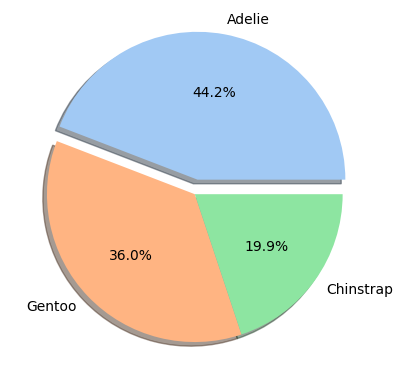

In [21]:
exp=[0.1, 0, 0]
plt.pie(species_count, 
        autopct='%.1f%%', 
        labels=species_count.index,
        shadow=True, 
        explode=exp)

样本中`Adelie`这个种类的企鹅占比最大, `Gentoo`次之, `Chinstrap`占比最小, 为1/5左右

### 企鹅所属岛屿比例

In [22]:
island_count = cleaned_penguins['island'].value_counts()
island_count

island
Biscoe       167
Dream        124
Torgersen     51
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x22274605a90>,
 [Text(0.04408253880339504, 1.1991900307176704, 'Biscoe'),
  Text(-0.5324063168406664, -0.9625713032228604, 'Dream'),
  Text(0.9814795839173, -0.49668684938653646, 'Torgersen')],
 [Text(0.025714814301980436, 0.699527517918641, '48.8%'),
  Text(-0.2904034455494544, -0.5250388926670148, '36.3%'),
  Text(0.5353525003185272, -0.2709200996653835, '14.9%')])

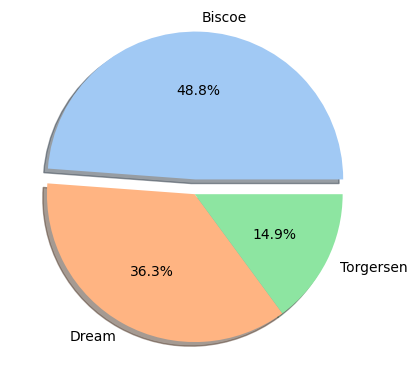

In [23]:
plt.pie(island_count,
       labels=island_count.index,
       autopct='%.1f%%',
       explode= exp,
       shadow=True)

样本中接近一半的企鹅都来自`Biscoe`岛, 占比最大, 其次是`dream`岛, 而来自`Torgersen`岛屿的样本最少

### 企鹅性别比例

In [25]:
sex_count = cleaned_penguins['sex'].value_counts()
sex_count

sex
MALE      168
FEMALE    165
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x22274e55c70>,
 [Text(-0.01556599676421093, 1.0998898580061263, 'MALE'),
  Text(0.015565699568373776, -1.0998898622120976, 'FEMALE')],
 [Text(-0.008490543689569597, 0.5999399225487961, '50.5%'),
  Text(0.008490381582749331, -0.5999399248429623, '49.5%')])

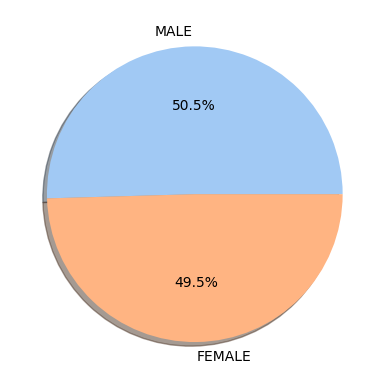

In [28]:
plt.pie(sex_count,
       labels=sex_count.index,
       autopct='%.1f%%',
       shadow=True)

样本企鹅性别比例持平, 符合性别属性随机抽样的规律

### 不同岛上的企鹅种类数量

<Axes: xlabel='island', ylabel='count'>

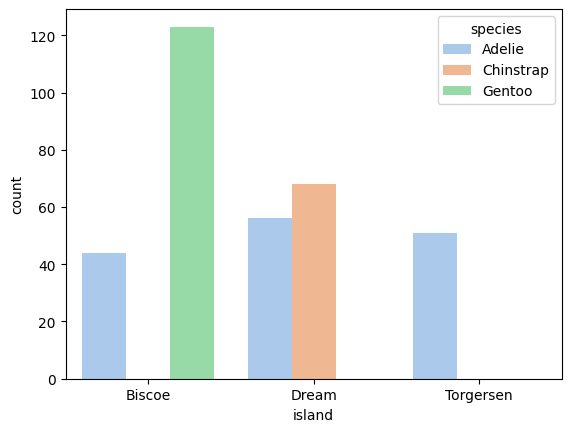

In [29]:
sns.countplot(cleaned_penguins, x='island', hue='species')

根据复式计数图, `Adelie`种类在每个岛上都有分布, 分布最广; 而`Chinstrap`和`Gentoo`则分别只在`Biscoe`岛和`Dream`岛上才有

### 不同岛上的企鹅性别数量

<Axes: xlabel='island', ylabel='count'>

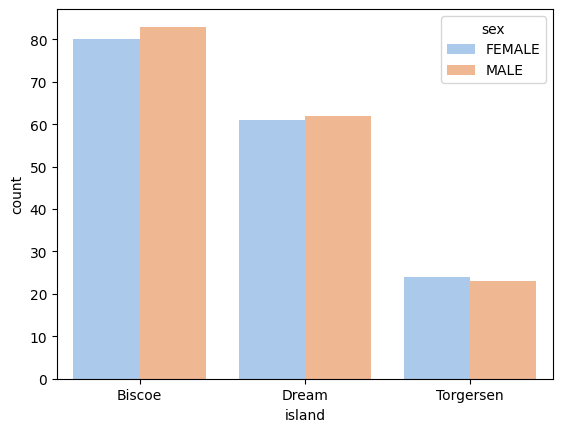

In [30]:
sns.countplot(cleaned_penguins, x='island', hue='sex')

根据复式计数图, 各个岛上的企鹅性别比例均接近1:1

接下来探索数值变量, 先用配对图一次性探索单个数值变量, 再深入观察数值变量的相关关系

### 查看数值之间的相关关系

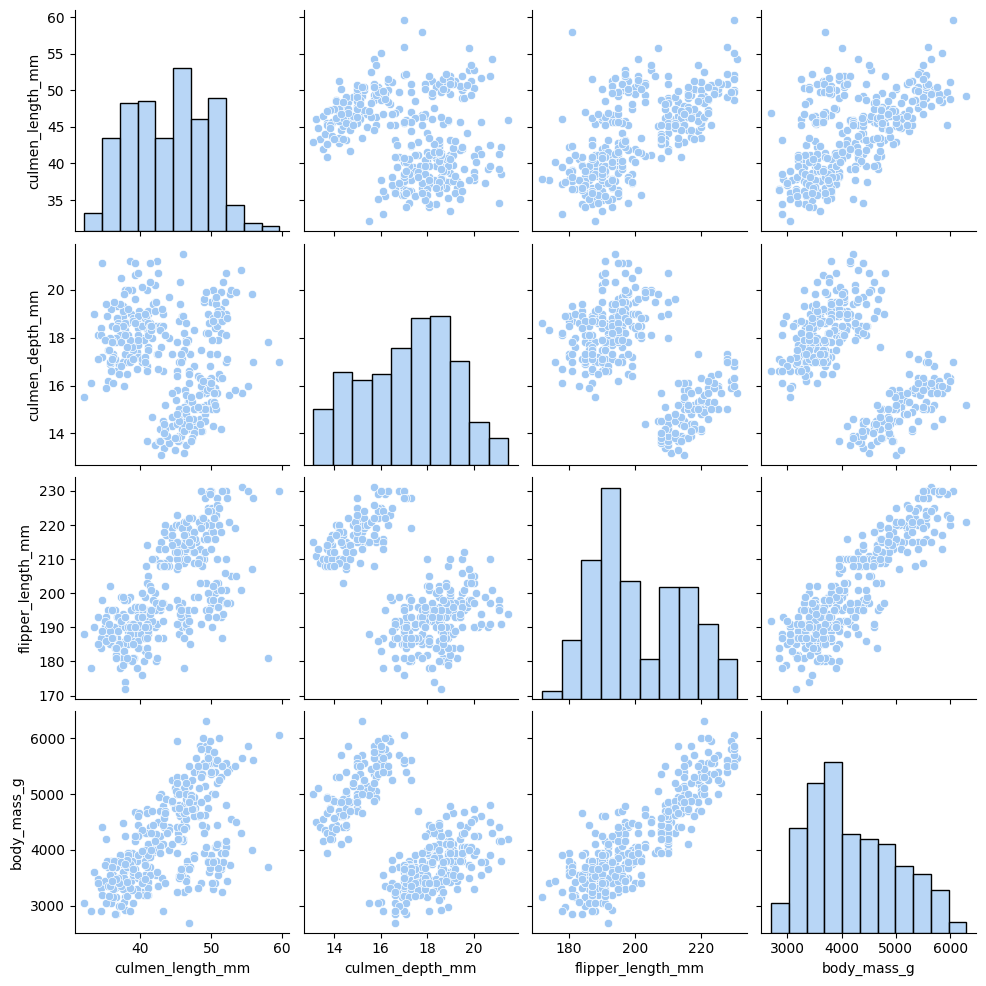

In [32]:
sns.pairplot(cleaned_penguins)

根据直方图, 企鹅样本的嘴峰长度, 嘴峰深度, 鳍长度和体重的分布不是正态分布, 而是呈现偏态或双峰的趋势. 一方面说明, 这里面可能包含了多组存在差异的样本数据, 另一方面也说明样本数不够大

此外, 散点图中可以明显看出多个集群, 这可能和某些因素有关, 如企鹅种类, 性别, 因此可以对对比图进行进一步分类  
(根据常识和前面岛屿和种类的关系, 我们不会把岛屿看成是主要影响因素)

### 根据种类查看数值之间的相关关系

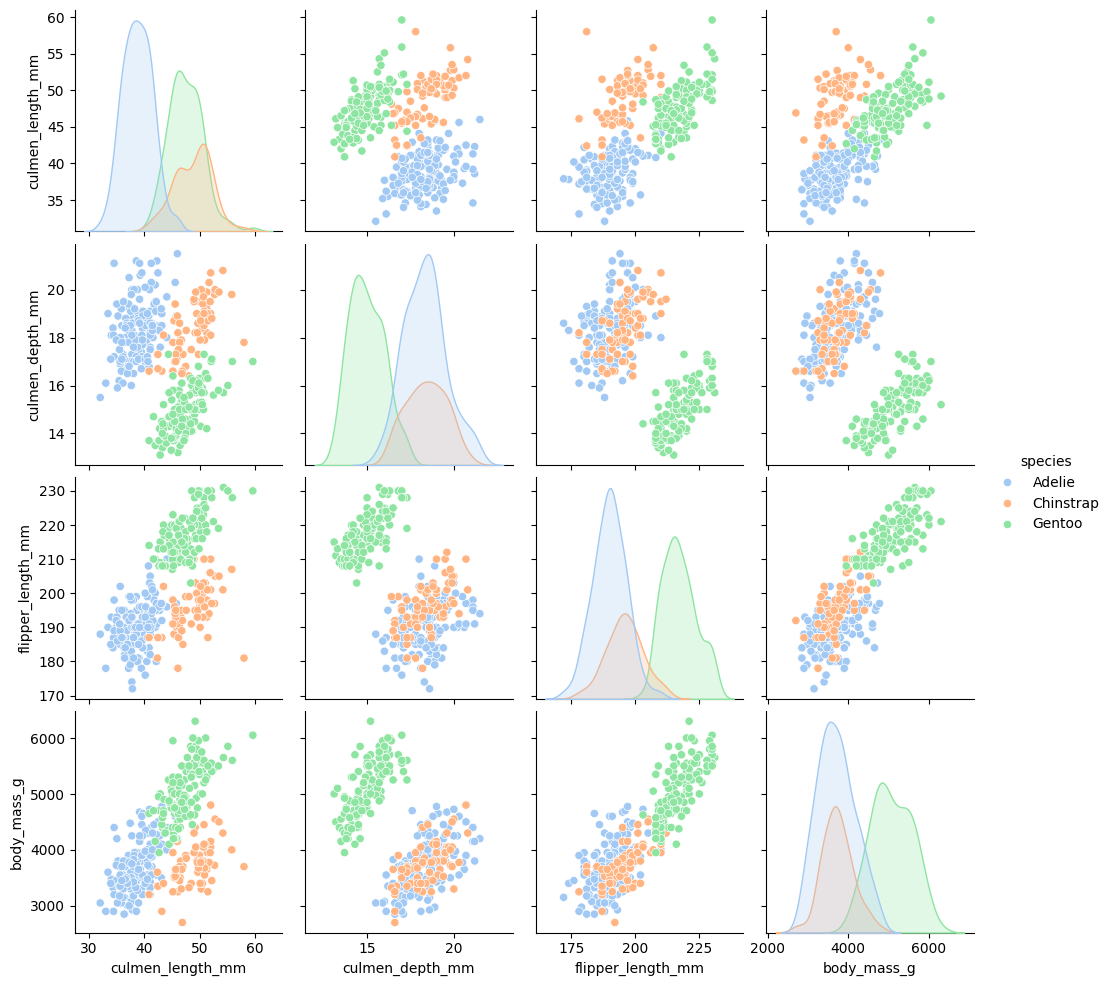

In [33]:
sns.pairplot(cleaned_penguins, hue='species')

同种类的企鹅样本数据, 在散点图上基本都聚在一起, 这说明同种类企鹅在嘴峰长度、嘴峰深度、鳍长度、体重这些身体属性之间的关系上，存在相似性。 后续对同种类企鹅的身体属性规律进行探索， 有助于科学家们根据这些属性的数值推测企鹅种类， 也可以根据企鹅种类推测其身体属性的数值信息。

尝试为散点图添加趋势线, 来使观察更清晰

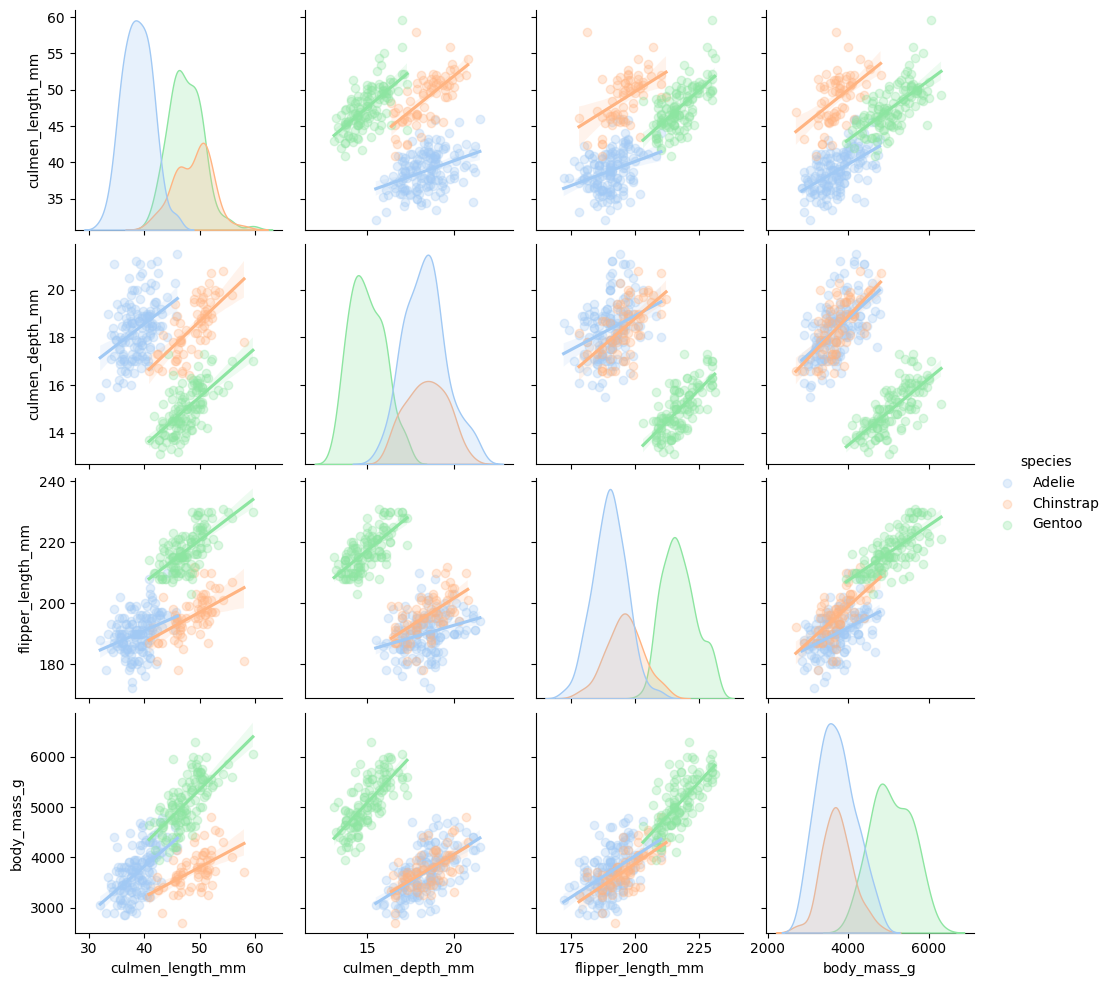

In [37]:
sns.pairplot(cleaned_penguins, hue='species', kind='reg', plot_kws={'scatter_kws':{'alpha': 0.3}})
# 最后一个参数, 是为了单独调整配对图中的散点图透明度

散点图结合线性回归线来看, 同类企鹅的属性数据之间均呈线性正比, 即即嘴峰越长，嘴峰越深，鳍越长，体重越重，嘴峰越短，嘴峰越浅，鳍越短，体重越轻。

关注密度图, 得到以下关于样本的发现:
- `Gentoo`和`Chinstrap`嘴峰长度范围较为接近, 而`Adelie`嘴峰长度更短
- `Adelie`和`Chinstrap`嘴峰深度范围较为接近, 而`Gentoo`嘴峰深度更短
- `Adelie`鳍长最短, `Chinstrap`中等, `Gentoo`最长
- `Adelie`和`Chinstrap`体重范围较为接近, 而`Gentoo`体重更大  


但不同种类属性数值是否存在统计显著性差异, 仍然要进行假设检验后才能得到结论.

### 根据性别查看数值之间的相关关系

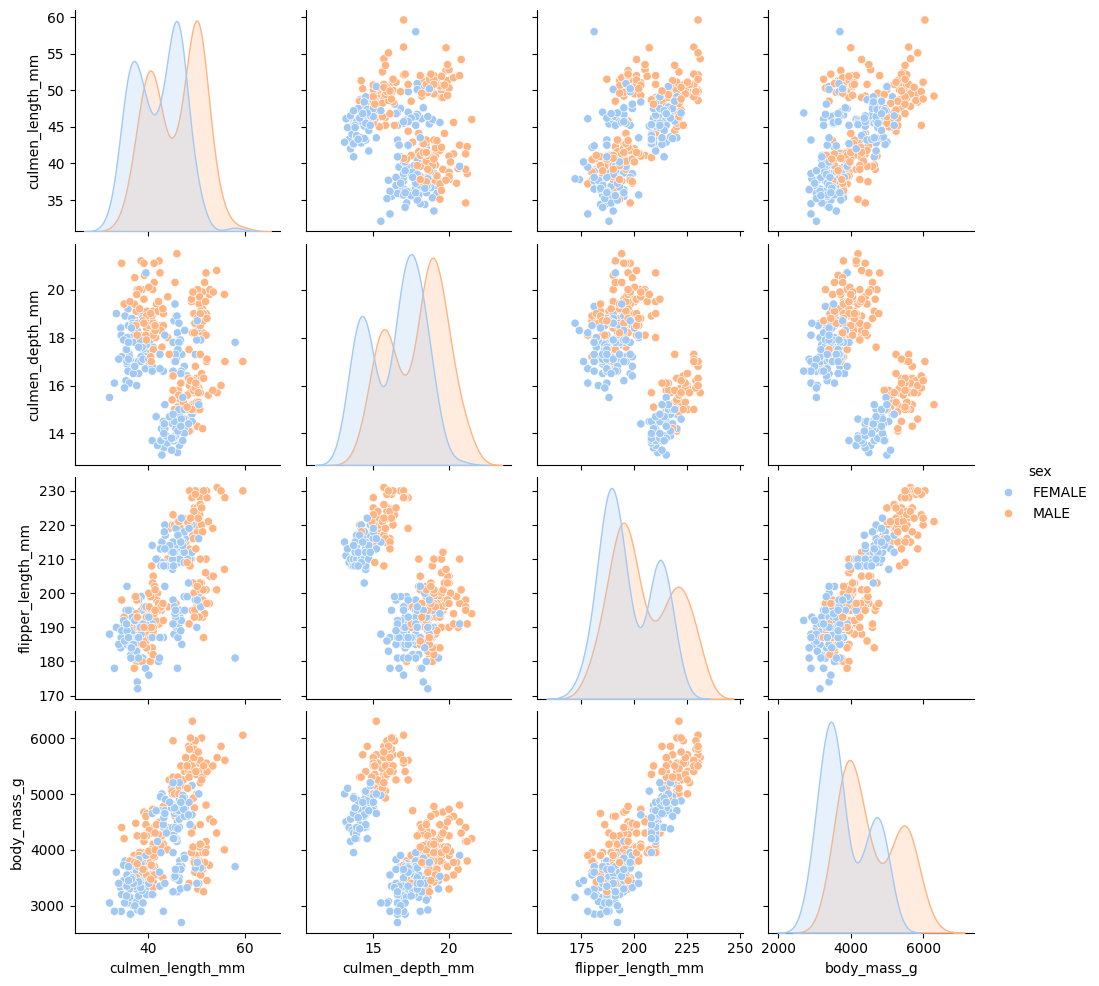

In [38]:
sns.pairplot(cleaned_penguins, hue='sex')

根据划分性别的配对图, 样本中的雄性企鹅在各项属性数值方面大于雌性企鹅